# 第9章：立体视觉点云重建

## 编程实践：从双视图到三维点云

| 项目 | 说明 |
|------|------|
| 数据集 | semper (经典SfM数据集) — 3张图像 + 相机内外参 + 地面真值3D点 |
| 核心内容 | 特征提取匹配 → 基础矩阵F → 本质矩阵E → 位姿恢复 → 三角化 → 点云重建 |
| 允许调用 | 图像读写 (cv2.imread)、矩阵计算 (numpy)、特征点提取与匹配 (SIFT/BFMatcher) |
| 必须手写 | 归一化8点法求F、E分解恢复R/t、cheirality选择、线性三角化 |
| 输出 | point_cloud.txt (X Y Z格式，可用CloudCompare查看) |
| 对比验证 | 与OpenCV结果对比，与地面真值对比，重投影误差 |

**手写约束**：除图像读写、矩阵运算、特征提取与匹配可调用 OpenCV/NumPy 外，
基础矩阵估计、本质矩阵分解、三角化等核心算法全部手写实现。

## 一、学习目标

1. 理解**对极几何**的基本概念：极点、极线、基础矩阵F、本质矩阵E。
2. 掌握**归一化8点法**求解基础矩阵F，理解rank-2约束的意义。
3. 掌握从本质矩阵E**分解恢复相机位姿**（R, t）的方法，理解cheirality约束。
4. 掌握**线性三角化**（DLT + SVD）恢复三维空间点坐标。
5. 学会评估重建质量：重投影误差、与地面真值对比。

### 知识图谱
```
双视图图像 → 特征匹配 → 基础矩阵F → 本质矩阵E → 相机位姿(R,t) → 三角化 → 3D点云
                    ↑              ↑            ↑               ↑
                 SIFT/BF      8点法       SVD分解        DLT+SVD
```


## 二、数据集介绍：semper

semper是经典的多视图立体视觉数据集，包含3张不同视角拍摄的雕像图像，以及：
- `.camera` 文件：相机内参K、畸变参数、旋转矩阵R、平移向量t、图像尺寸
- `.3Dpoints` 文件：地面真值三维点坐标（可用于评估重建精度）

### 相机参数文件格式
```
第1-3行：3×3 相机内参矩阵 K
第4行：  3个径向畸变参数（全为0表示已校正）
第5-7行：3×3 旋转矩阵 R（相机到世界的旋转，列向量为相机轴）
第8行：  3维平移向量 t（相机光心在世界坐标系中的位置）
第9行：  图像尺寸 宽 高
```

投影公式：$x = K [R^T | -R^T t] X$，其中 X 为世界坐标中的三维点。


In [1]:
import sys
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# 项目根目录基础设施（中文路径读写、随机种子、可视化）
sys.path.insert(0, str(Path.cwd().resolve().parents[2]))
from utils import set_random_seed

# 数据集路径：semper 数据（rdimage.*.ppm 等）与 notebook 同目录
# 依次尝试：当前目录 -> 同级 semper/ -> 上级 semper/ -> 用户下载目录
_CANDIDATES = [
    Path("."),
    Path("semper"),
    Path("../semper"),
    Path.home() / "download" / "semper (2)",
    Path.home() / "Downloads" / "semper (2)",
]
DATA_DIR = next(
    (c for c in _CANDIDATES if (c / "rdimage.000.ppm").exists()),
    _CANDIDATES[0],
)
print(f"数据集目录: {DATA_DIR.resolve()}")
assert (DATA_DIR / "rdimage.000.ppm").exists(), (
    f"找不到 semper 数据集（rdimage.000.ppm）: {DATA_DIR.resolve()}"
)

# 固定随机种子，保证 RANSAC / 随机采样结果可复现
set_random_seed(42)

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False


数据集目录: D:\CODE\Hands-On-Computer-Vision\notebooks\part2-optimization-3d\09-stereo-reconstruction


### 2.1 读取相机参数

我们编写函数读取 `.camera` 文件，解析内参K、旋转R、平移t等参数。

In [2]:
def load_camera_params(camera_file):
    """读取semper格式的相机参数文件。
    
    返回: K (3x3), dist (3,), R_c2w (3x3), t_c2w (3,), width, height
    R_c2w: 相机到世界的旋转矩阵（列是相机坐标轴在世界中的方向）
    t_c2w: 相机光心在世界坐标系中的位置
    """
    with open(camera_file, 'r') as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]
    
    # 第1-3行: K
    K = np.array([list(map(float, lines[i].split())) for i in range(3)], dtype=np.float64)
    # 第4行: 畸变
    dist = np.array(list(map(float, lines[3].split())), dtype=np.float64)
    # 第5-7行: R (相机到世界)
    R_c2w = np.array([list(map(float, lines[4+i].split())) for i in range(3)], dtype=np.float64)
    # 第8行: t (相机中心在世界中)
    t_c2w = np.array(list(map(float, lines[7].split())), dtype=np.float64)
    # 第9行: 图像尺寸
    w, h = map(int, lines[8].split())
    
    return K, dist, R_c2w, t_c2w, w, h


def get_projection_matrix(R_c2w, t_c2w, K):
    """计算投影矩阵 P = K [R^T | -R^T t]。
    
    世界到相机的变换: X_cam = R_w2c * X_world + t_w2c
    其中 R_w2c = R_c2w^T, t_w2c = -R_c2w^T * t_c2w
    """
    R_w2c = R_c2w.T  # 世界到相机的旋转
    t_w2c = -R_c2w.T @ t_c2w  # 世界到相机的平移
    P = K @ np.hstack([R_w2c, t_w2c.reshape(3, 1)])
    return P, R_w2c, t_w2c


# 加载前两张图像的相机参数
K1, dist1, R1_c2w, t1_c2w, w1, h1 = load_camera_params(DATA_DIR / "rdimage.000.ppm.camera")
K2, dist2, R2_c2w, t2_c2w, w2, h2 = load_camera_params(DATA_DIR / "rdimage.001.ppm.camera")

print("=== 相机1内参 K1 ===")
print(K1)
print(f"图像尺寸: {w1} x {h1}")
print(f"相机中心 (世界坐标): {t1_c2w}")
print()
print("=== 相机2内参 K2 ===")
print(K2)
print(f"图像尺寸: {w2} x {h2}")
print(f"相机中心 (世界坐标): {t2_c2w}")


=== 相机1内参 K1 ===
[[2.78017e+03 0.00000e+00 1.53925e+03]
 [0.00000e+00 2.77354e+03 1.00127e+03]
 [0.00000e+00 0.00000e+00 1.00000e+00]]
图像尺寸: 3072 x 2048
相机中心 (世界坐标): [-0.788193  0.261723  1.12968 ]

=== 相机2内参 K2 ===
[[2.78017e+03 0.00000e+00 1.53925e+03]
 [0.00000e+00 2.77354e+03 1.00127e+03]
 [0.00000e+00 0.00000e+00 1.00000e+00]]
图像尺寸: 3072 x 2048
相机中心 (世界坐标): [-0.0768755  0.213745   1.00439  ]


### 2.2 读取并可视化图像

semper数据集图像尺寸较大（3072×2048），我们先缩小以便处理。

原图尺寸: 3072x2048
缩放后尺寸: 768x512 (scale=0.25)


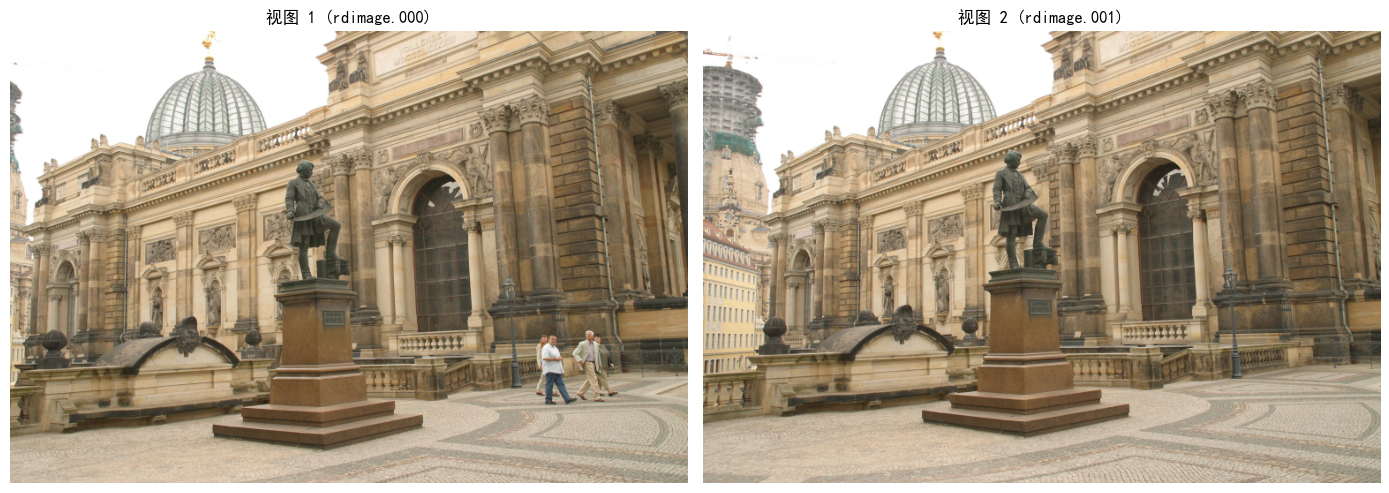

In [3]:
# 读取图像（缩小尺寸以加快处理速度）
scale = 0.25  # 缩放因子

img1_full = cv2.imread(str(DATA_DIR / "rdimage.000.ppm"))
img2_full = cv2.imread(str(DATA_DIR / "rdimage.001.ppm"))

img1 = cv2.resize(img1_full, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
img2 = cv2.resize(img2_full, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

print(f"原图尺寸: {img1_full.shape[1]}x{img1_full.shape[0]}")
print(f"缩放后尺寸: {img1.shape[1]}x{img1.shape[0]} (scale={scale})")

# 更新缩放后的内参
K1_scaled = K1.copy()
K1_scaled[0, :] *= scale  # fx, cx
K1_scaled[1, :] *= scale  # fy, cy
K2_scaled = K2.copy()
K2_scaled[0, :] *= scale
K2_scaled[1, :] *= scale

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[0].set_title('视图 1 (rdimage.000)')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[1].set_title('视图 2 (rdimage.001)')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## 三、对极几何基础

对极几何描述了双视图之间的内在几何约束，与场景结构无关，仅取决于相机内参和相对位姿。

### 3.1 核心概念

- **对极点 (epipole)**：另一相机光心在本图像平面上的投影，记为 $e_1, e_2$
- **极线 (epipolar line)**：对极平面与图像平面的交线。左图中一点 $x_1$，对应右图中匹配点必在极线 $l_2$ 上
- **基础矩阵 F**：描述像素坐标下的对极约束 $x_2^T F x_1 = 0$，7个自由度
- **本质矩阵 E**：描述归一化坐标下的对极约束 $\hat{x}_2^T E \hat{x}_1 = 0$，5个自由度

### 3.2 F 与 E 的关系

$$E = K_2^T F K_1$$

其中 $K_1, K_2$ 分别为左右相机的内参矩阵。

### 3.3 对极约束

左图中一点 $x_1$，其在右图中的对应点 $x_2$ 一定落在极线 $l_2 = F x_1$ 上。反之，$l_1 = F^T x_2$。


## 四、基础矩阵 F 估计：归一化 8 点法

### 4.1 8点法原理

每对匹配点 $(x_1, y_1)$ 和 $(x_2, y_2)$ 给出一个方程：

$$x_2 x_1 f_{11} + x_2 y_1 f_{12} + x_2 f_{13} + y_2 x_1 f_{21} + y_2 y_1 f_{22} + y_2 f_{23} + x_1 f_{31} + y_1 f_{32} + f_{33} = 0$$

8对点可构造8×9的矩阵A，对A做SVD，最小奇异值对应的右奇异向量即为F（拉直成3×3）。

### 4.2 为什么需要归一化？

直接使用像素坐标求解时，矩阵A通常是病态的（条件数很大），导致结果不稳定。
**Hartley归一化**：将点平移到原点并缩放使平均距离为 $\sqrt{2}$，求解后再变换回来。

### 4.3 rank-2 约束

基础矩阵的秩必须为2（奇异值有一个为0），否则对极约束不严格成立。求解后需将最小奇异值置零。


### 4.1 SIFT特征提取与匹配

首先提取两幅图像的SIFT特征点，并用BFMatcher+Lowe比率测试筛选良好匹配。

图1特征点数: 2000
图2特征点数: 2000
良好匹配对数: 992


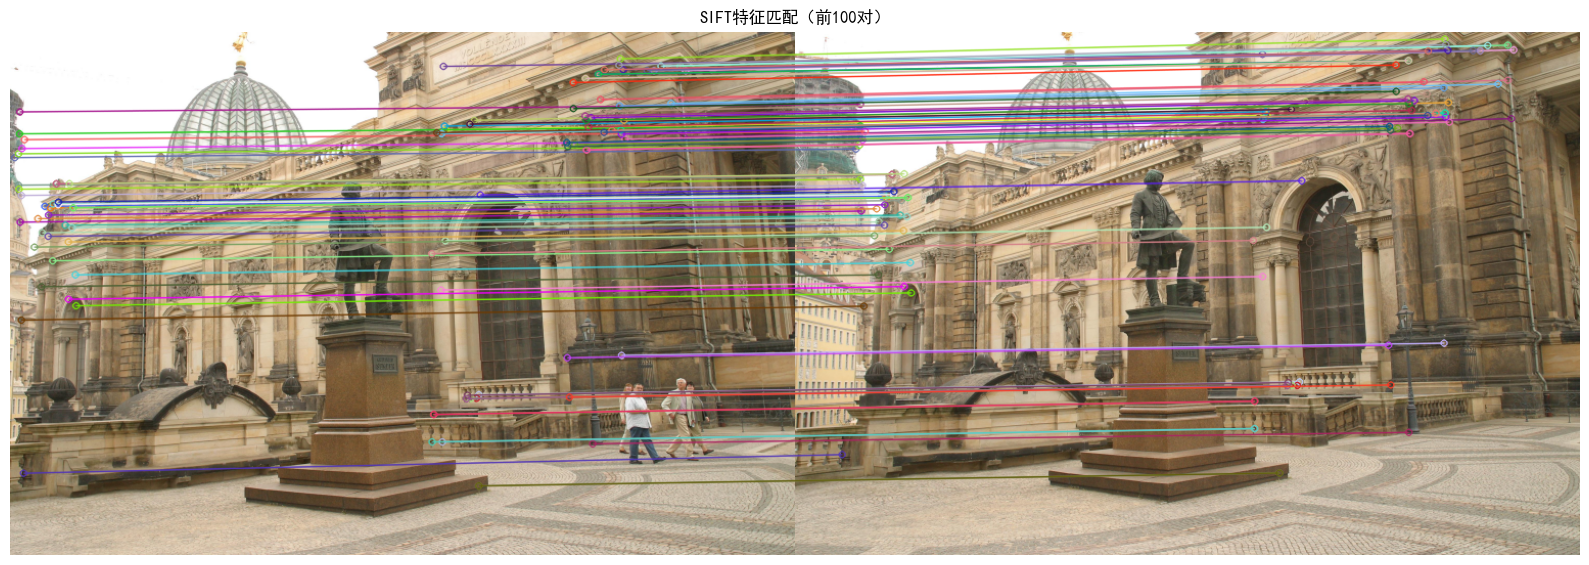

In [4]:
# SIFT特征提取
sift = cv2.SIFT_create(nfeatures=2000)
kp1, des1 = sift.detectAndCompute(img1_gray, None)
kp2, des2 = sift.detectAndCompute(img2_gray, None)
print(f"图1特征点数: {len(kp1)}")
print(f"图2特征点数: {len(kp2)}")

# BF匹配 + Lowe比率测试
bf = cv2.BFMatcher(cv2.NORM_L2)
knn_matches = bf.knnMatch(des1, des2, k=2)

good_matches = []
for m, n in knn_matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"良好匹配对数: {len(good_matches)}")

# 提取匹配点坐标
pts1 = np.float64([kp1[m.queryIdx].pt for m in good_matches])
pts2 = np.float64([kp2[m.trainIdx].pt for m in good_matches])

# 可视化匹配
img_match = cv2.drawMatches(img1, kp1, img2, kp2, good_matches[:100], None, 
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB))
plt.title('SIFT特征匹配（前100对）')
plt.axis('off')
plt.tight_layout()
plt.show()


### 4.2 手写：归一化 8 点法求 F

**步骤**：
1. 对两组点分别做Hartley归一化（平移质心到原点，平均距离为√2）
2. 构造A矩阵（N×9），每行为对应点的线性方程系数
3. SVD分解A，取最小奇异值对应的右奇异向量作为F的初值
4. 对F做SVD，将最小奇异值置0（强制rank=2）
5. 反归一化：$F = T_2^T F_{norm} T_1$
6. 归一化使 F[2,2] = 1

In [5]:
import math

def normalize_points(pts):
    """Hartley归一化：平移质心到原点，缩放到平均距离为 sqrt(2)。
    
    返回: 3x3 变换矩阵 T，满足 p_norm = T @ p_homogeneous
    """
    pts = np.asarray(pts, dtype=np.float64)
    # 质心
    centroid = pts.mean(axis=0)
    # 各点到质心的平均距离
    dists = np.linalg.norm(pts - centroid, axis=1)
    mean_dist = dists.mean()
    # 缩放因子
    scale = math.sqrt(2.0) / mean_dist
    # 构造变换矩阵
    T = np.array([
        [scale, 0, -scale * centroid[0]],
        [0, scale, -scale * centroid[1]],
        [0, 0, 1]
    ])
    return T


def compute_fundamental_8point(pts1, pts2):
    """手写归一化8点法求基础矩阵 F。
    
    输入: pts1, pts2 - N×2 的匹配点坐标（像素）
    输出: 3×3 基础矩阵 F（F[2,2]=1 归一化）
    """
    N = len(pts1)
    assert N >= 8, "至少需要8对匹配点"
    
    # 步骤1: 归一化
    T1 = normalize_points(pts1)
    T2 = normalize_points(pts2)
    
    # 将点转为齐次坐标并归一化
    pts1_h = np.hstack([pts1, np.ones((N, 1))])  # N×3
    pts2_h = np.hstack([pts2, np.ones((N, 1))])
    p1_norm = (T1 @ pts1_h.T).T  # N×3
    p2_norm = (T2 @ pts2_h.T).T
    
    # 步骤2: 构造A矩阵 (N×9)
    A = np.zeros((N, 9))
    for i in range(N):
        x1, y1, _ = p1_norm[i]
        x2, y2, _ = p2_norm[i]
        A[i] = [x2*x1, x2*y1, x2, y2*x1, y2*y1, y2, x1, y1, 1.0]
    
    # 步骤3: SVD分解A，取最小奇异值对应的向量
    _, _, Vt = np.linalg.svd(A)
    F_norm = Vt[-1].reshape(3, 3)
    
    # 步骤4: 强制rank=2（将最小奇异值置0）
    U, S, Vt = np.linalg.svd(F_norm)
    S[2] = 0.0
    F_norm = U @ np.diag(S) @ Vt
    
    # 步骤5: 反归一化
    F = T2.T @ F_norm @ T1
    
    # 步骤6: 归一化使F[2,2]=1
    F = F / F[2, 2]
    
    return F


# 测试：手写8点法
F_my = compute_fundamental_8point(pts1, pts2)
print("=== 手写8点法 F ===")
print(F_my)

# OpenCV对比
F_cv, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_8POINT)
print("\n=== OpenCV F (8POINT) ===")
print(F_cv)

# 验证对极约束：x2^T F x1 应该接近0
errors = []
for i in range(len(pts1)):
    x1 = np.array([pts1[i, 0], pts1[i, 1], 1.0])
    x2 = np.array([pts2[i, 0], pts2[i, 1], 1.0])
    err = x2 @ F_my @ x1
    errors.append(abs(err))
print(f"\n对极约束误差 (平均): {np.mean(errors):.6f}")
print(f"对极约束误差 (中位数): {np.median(errors):.6f}")


=== 手写8点法 F ===
[[ 5.67239738e-07  1.60410564e-05 -1.15695837e-02]
 [-1.96004734e-05 -7.42867062e-07  5.77968042e-02]
 [ 1.17168113e-02 -5.70983253e-02  1.00000000e+00]]

=== OpenCV F (8POINT) ===
[[ 5.67239738e-07  1.60410564e-05 -1.15695837e-02]
 [-1.96004734e-05 -7.42867062e-07  5.77968042e-02]
 [ 1.17168113e-02 -5.70983253e-02  1.00000000e+00]]

对极约束误差 (平均): 0.101227
对极约束误差 (中位数): 0.033558


### 4.3 极线可视化

利用求出的F，计算左图特征点在右图中的极线，验证对极约束的正确性。

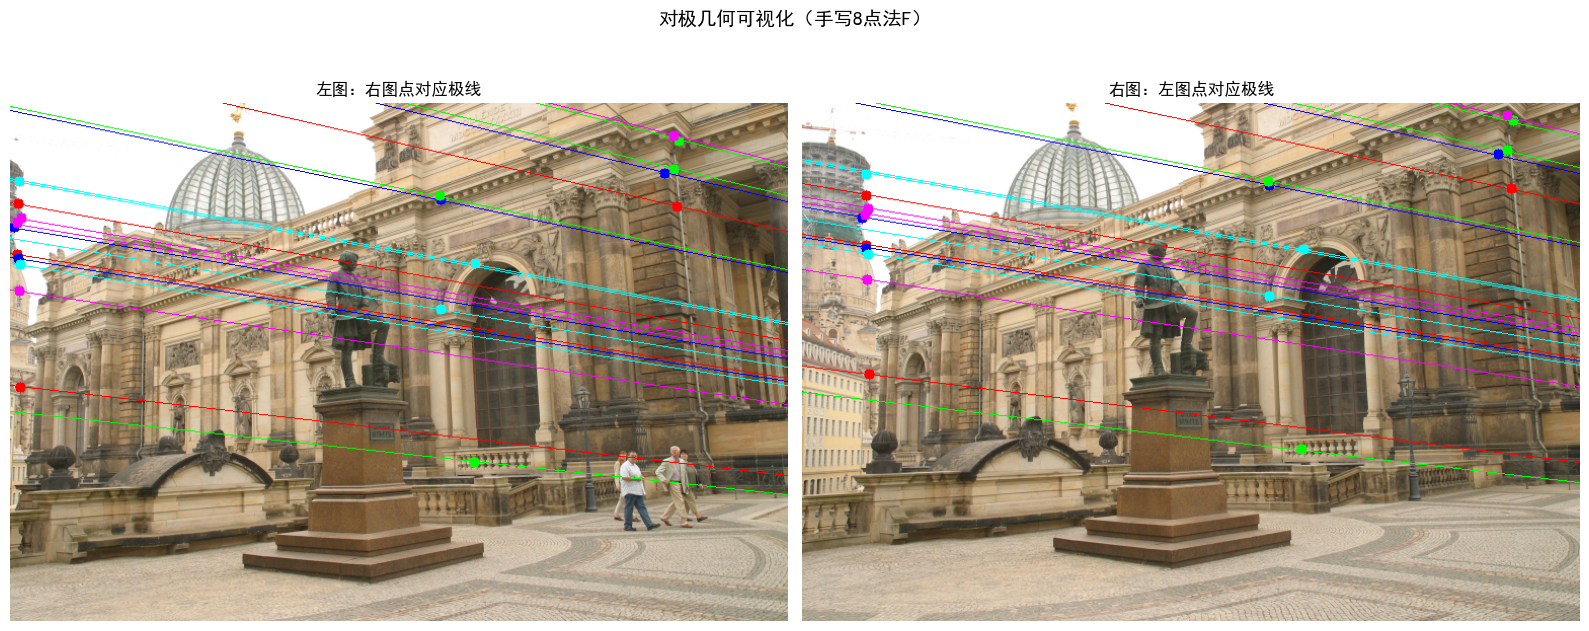

In [6]:
def draw_epipolar_lines(img1, img2, pts1, pts2, F):
    """在右图上画出左图点对应的极线，在左图上画出右图点对应的极线。"""
    h, w = img1.shape[:2]
    
    # 左图点 → 右图极线: l2 = F @ x1
    pts1_h = np.hstack([pts1, np.ones((len(pts1), 1))])
    lines2 = (F @ pts1_h.T).T  # N×3
    
    # 右图点 → 左图极线: l1 = F^T @ x2
    pts2_h = np.hstack([pts2, np.ones((len(pts2), 1))])
    lines1 = (F.T @ pts2_h.T).T
    
    img1_lines = img1.copy()
    img2_lines = img2.copy()
    
    colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255)]
    
    # 在左图上画极线和点
    for i in range(min(20, len(pts1))):  # 只画前20条避免太乱
        color = colors[i % len(colors)]
        # 左图上的极线
        a, b, c = lines1[i]
        x0, y0 = 0, int(-c / b) if abs(b) > 1e-6 else 0
        x1_line, y1_line = w, int(-(a * w + c) / b) if abs(b) > 1e-6 else 0
        cv2.line(img1_lines, (x0, y0), (x1_line, y1_line), color, 1)
        cv2.circle(img1_lines, (int(pts1[i, 0]), int(pts1[i, 1])), 5, color, -1)
        
        # 右图上的极线
        a, b, c = lines2[i]
        x0, y0 = 0, int(-c / b) if abs(b) > 1e-6 else 0
        x2_line, y2_line = w, int(-(a * w + c) / b) if abs(b) > 1e-6 else 0
        cv2.line(img2_lines, (x0, y0), (x2_line, y2_line), color, 1)
        cv2.circle(img2_lines, (int(pts2[i, 0]), int(pts2[i, 1])), 5, color, -1)
    
    return img1_lines, img2_lines


img1_epi, img2_epi = draw_epipolar_lines(img1, img2, pts1[:20], pts2[:20], F_my)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(cv2.cvtColor(img1_epi, cv2.COLOR_BGR2RGB))
axes[0].set_title('左图：右图点对应极线')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(img2_epi, cv2.COLOR_BGR2RGB))
axes[1].set_title('右图：左图点对应极线')
axes[1].axis('off')
plt.suptitle('对极几何可视化（手写8点法F）', fontsize=14)
plt.tight_layout()
plt.show()


## 五、本质矩阵 E 与相机位姿恢复

### 5.1 本质矩阵 E

本质矩阵描述了归一化图像坐标下的对极几何关系：

$$E = K_2^T F K_1$$

与F不同，E的奇异值具有特殊结构：两个相等的非零奇异值和一个零奇异值，即 $diag(\sigma, \sigma, 0)$。

### 5.2 从 E 恢复相机位姿

对 E 做SVD分解：$E = U \Sigma V^T$

可得到4组可能的 (R, t) 解：
$$R_1 = U W V^T, \quad R_2 = U W^T V^T$$
$$t = \pm u_3$$

其中 $W = \begin{bmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 1 \end{bmatrix}$，$u_3$ 是 U 的第3列。

### 5.3 Cheirality 约束（正深度检验）

4组解中只有一组能使大多数重建点在两个相机前方（深度为正）。这就是**cheirality约束**。

设相机1的投影矩阵为 $P_1 = K[I | 0]$，相机2的候选投影矩阵为 $P_2 = K[R | t]$，
对匹配点做三角化得到3D点X，检验X在两相机坐标系中的Z坐标是否均为正。


In [7]:
def compute_essential(K1, K2, F):
    """由基础矩阵F和内参计算本质矩阵E。"""
    E = K2.T @ F @ K1
    # 修正E的奇异值为[1,1,0]结构（可选，使E更接近真实本质矩阵）
    U, S, Vt = np.linalg.svd(E)
    S = np.array([(S[0]+S[1])/2, (S[0]+S[1])/2, 0.0])
    E = U @ np.diag(S) @ Vt
    return E


def decompose_essential(E):
    """对本质矩阵E做SVD分解，返回4组候选 (R, t)。
    
    注意：返回的R和t是从相机1到相机2的变换（即相机2在相机1坐标系下的位姿）。
    X_cam2 = R @ X_cam1 + t
    """
    U, S, Vt = np.linalg.svd(E)
    
    # 确保det(U)=1, det(V)=1（旋转矩阵行列式为+1）
    if np.linalg.det(U) < 0:
        U = -U
    if np.linalg.det(Vt) < 0:
        Vt = -Vt
    
    W = np.array([[0, -1, 0], [1, 0, 0], [0, 0, 1]], dtype=np.float64)
    
    R1 = U @ W @ Vt
    R2 = U @ W.T @ Vt
    t = U[:, 2]  # 平移方向（U的第3列）
    
    # 4组候选解
    candidates = [
        (R1, t),
        (R1, -t),
        (R2, t),
        (R2, -t),
    ]
    
    # 确保R是旋转矩阵（行列式=1）
    candidates = [(R / np.linalg.det(R)**(1/3), t) if abs(np.linalg.det(R) - 1) > 1e-6 else (R, t) for R, t in candidates]
    
    return candidates


# 计算本质矩阵
E = compute_essential(K1_scaled, K2_scaled, F_my)
print("=== 本质矩阵 E ===")
print(E)
print(f"\nE的奇异值: {np.linalg.svd(E)[1]}")

# 分解E得到4组候选
candidates = decompose_essential(E)
print(f"\n候选 (R, t) 组数: {len(candidates)}")
for i, (R, t) in enumerate(candidates):
    print(f"\n候选 {i+1}: det(R)={np.linalg.det(R):.6f}, t方向={t / np.linalg.norm(t)}")


=== 本质矩阵 E ===
[[  0.2641031    7.63013178  -5.0092299 ]
 [ -9.55466688   0.15009767  34.84464686]
 [  5.0017449  -35.30611695   0.4294634 ]]

E的奇异值: [3.64730615e+01 3.64730615e+01 1.23135265e-15]

候选 (R, t) 组数: 4

候选 1: det(R)=1.000000, t方向=[-0.96815333 -0.13659476 -0.2098118 ]

候选 2: det(R)=1.000000, t方向=[0.96815333 0.13659476 0.2098118 ]

候选 3: det(R)=1.000000, t方向=[-0.96815333 -0.13659476 -0.2098118 ]

候选 4: det(R)=1.000000, t方向=[0.96815333 0.13659476 0.2098118 ]


## 六、线性三角化与 Cheirality 选择

### 6.1 线性三角化（DLT方法）

已知两相机投影矩阵 $P_1, P_2$ 和对应匹配点 $x_1, x_2$，求三维点 $X$。

由 $x_1 = P_1 X$ 和 $x_2 = P_2 X$，利用叉乘消去齐次因子，构造4×4线性方程组：

$$A = \begin{bmatrix} x_1 p_1^{3T} - p_1^{1T} \\ y_1 p_1^{3T} - p_1^{2T} \\ x_2 p_2^{3T} - p_2^{1T} \\ y_2 p_2^{3T} - p_2^{2T} \end{bmatrix}$$

其中 $p_i^{jT}$ 表示 $P_i$ 的第j行。对A做SVD，最小奇异值对应的右奇异向量即为齐次坐标下的X。

### 6.2 Cheirality选择

用三角化结果检验4组 (R, t) 中哪一组能让最多的点在两个相机前方（深度>0）。

In [8]:
def triangulate_linear(P1, P2, pts1, pts2):
    """手写线性三角化：DLT + SVD。
    
    输入:
        P1, P2: 3×4 投影矩阵
        pts1, pts2: N×2 匹配点（像素坐标）
    输出:
        N×3 三维点坐标（非齐次）
    """
    N = len(pts1)
    points_3d = np.zeros((N, 3), dtype=np.float64)
    
    for i in range(N):
        x1, y1 = pts1[i]
        x2, y2 = pts2[i]
        
        # 构造4×4矩阵A
        A = np.zeros((4, 4))
        A[0] = x1 * P1[2] - P1[0]
        A[1] = y1 * P1[2] - P1[1]
        A[2] = x2 * P2[2] - P2[0]
        A[3] = y2 * P2[2] - P2[1]
        
        # SVD求解
        _, _, Vt = np.linalg.svd(A)
        X_hom = Vt[-1]  # 齐次坐标
        X_hom = X_hom / X_hom[3]  # 归一化
        points_3d[i] = X_hom[:3]
    
    return points_3d


def cheirality_check(K1, K2, pts1, pts2, candidates):
    """在4组 (R, t) 候选中，选择正深度点最多的解。
    
    设相机1为参考: P1 = K1 [I | 0]
    相机2: P2 = K2 [R | t]
    """
    P1 = K1 @ np.hstack([np.eye(3), np.zeros((3, 1))])
    
    best_score = -1
    best_R = None
    best_t = None
    best_points = None
    
    for R, t in candidates:
        P2 = K2 @ np.hstack([R, t.reshape(3, 1)])
        X = triangulate_linear(P1, P2, pts1, pts2)
        
        # 相机1坐标系下的深度（Z坐标）
        depth1 = X[:, 2]
        
        # 转换到相机2坐标系: X_cam2 = R @ X + t
        X_cam2 = (R @ X.T + t.reshape(3, 1)).T
        depth2 = X_cam2[:, 2]
        
        # 正深度点的数量
        score = int(np.sum((depth1 > 0) & (depth2 > 0)))
        
        if score > best_score:
            best_score = score
            best_R = R
            best_t = t
            best_points = X
    
    return best_R, best_t, best_points, best_score


# Cheirality选择正确的 (R, t)
R_recovered, t_recovered, points_3d_recovered, n_positive = cheirality_check(
    K1_scaled, K2_scaled, pts1, pts2, candidates
)

print(f"正深度点数量: {n_positive} / {len(pts1)}")
print(f"\n恢复的旋转矩阵 R (相机2相对于相机1):")
print(R_recovered)
print(f"\n恢复的平移向量 t (相机2相对于相机1):")
print(t_recovered)
print(f"平移模长: {np.linalg.norm(t_recovered):.4f}")


正深度点数量: 588 / 992

恢复的旋转矩阵 R (相机2相对于相机1):
[[ 9.98530499e-01  1.00932947e-03  5.41832428e-02]
 [-7.65669488e-04  9.99989503e-01 -4.51753208e-03]
 [-5.41872337e-02  4.46940711e-03  9.98520790e-01]]

恢复的平移向量 t (相机2相对于相机1):
[-0.96815333 -0.13659476 -0.2098118 ]
平移模长: 1.0000


## 七、与地面真值对比

semper数据集提供了真实的相机位姿，我们可以将我们恢复的位姿与真值对比。

注意：从8点法+E分解恢复的位姿只有**尺度未定**（平移方向正确，但绝对值未知），因为对极几何无法确定绝对尺度。

In [9]:
# 计算地面真值的相对位姿（相机2相对于相机1）
# 世界→相机1: R_w2c_1, t_w2c_1
# 世界→相机2: R_w2c_2, t_w2c_2
# 相机1→相机2: R = R_w2c_2 @ R_w2c_1^T, t = t_w2c_2 - R @ t_w2c_1

# 从.camera文件获取世界到相机的变换
R1_w2c = R1_c2w.T  # R_c2w的转置就是世界到相机的旋转
t1_w2c = -R1_c2w.T @ t1_c2w  # 世界到相机的平移

R2_w2c = R2_c2w.T
t2_w2c = -R2_c2w.T @ t2_c2w

# 相机1 → 相机2 的相对变换
R_gt_rel = R2_w2c @ R1_w2c.T  # 相对旋转
t_gt_rel = t2_w2c - R_gt_rel @ t1_w2c  # 相对平移

print("=== 地面真值相对位姿 (相机2在相机1坐标系下) ===")
print("R_gt:")
print(R_gt_rel)
print("t_gt (原始尺度):")
print(t_gt_rel)
print(f"t_gt方向: {t_gt_rel / np.linalg.norm(t_gt_rel)}")

print("\n=== 恢复的位姿 ===")
print("R_recovered:")
print(R_recovered)
print("t_recovered方向:")
print(t_recovered / np.linalg.norm(t_recovered))

# 旋转误差（用角度表示）
R_diff = R_recovered @ R_gt_rel.T
trace = np.trace(R_diff)
angle = np.arccos(np.clip((trace - 1) / 2, -1, 1)) * 180 / np.pi
print(f"\n旋转误差: {angle:.4f} 度")

# 平移方向误差（夹角）
t1_norm = t_recovered / np.linalg.norm(t_recovered)
t2_norm = t_gt_rel / np.linalg.norm(t_gt_rel)
cos_angle = np.dot(t1_norm, t2_norm)
t_angle = np.arccos(np.clip(cos_angle, -1, 1)) * 180 / np.pi
print(f"平移方向误差: {t_angle:.4f} 度")


=== 地面真值相对位姿 (相机2在相机1坐标系下) ===
R_gt:
[[ 0.9977479   0.00247937  0.06702967]
 [-0.0011878   0.999813   -0.01930163]
 [-0.06706499  0.01917855  0.99756427]]
t_gt (原始尺度):
[-0.71167618  0.03820242  0.12660827]
t_gt方向: [-0.98316942  0.05277604  0.17490734]

=== 恢复的位姿 ===
R_recovered:
[[ 9.98530499e-01  1.00932947e-03  5.41832428e-02]
 [-7.65669488e-04  9.99989503e-01 -4.51753208e-03]
 [-5.41872337e-02  4.46940711e-03  9.98520790e-01]]
t_recovered方向:
[-0.96815333 -0.13659476 -0.2098118 ]

旋转误差: 1.1240 度
平移方向误差: 24.7761 度


## 八、三维点云可视化

将三角化得到的三维点云从不同视角展示，观察重建效果。

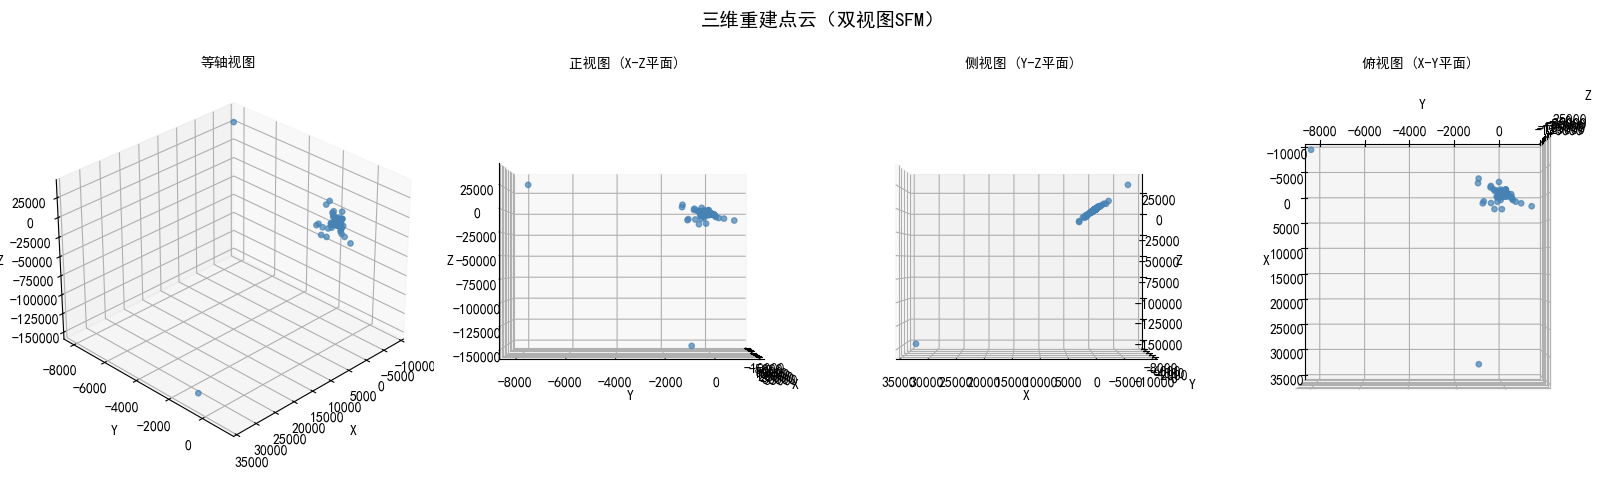

In [10]:
# 3D点云多视角可视化
fig = plt.figure(figsize=(16, 5))

views = [
    (30, 45, '等轴视图'),
    (0, 0, '正视图 (X-Z平面)'),
    (0, 90, '侧视图 (Y-Z平面)'),
    (90, 0, '俯视图 (X-Y平面)'),
]

for i, (elev, azim, title) in enumerate(views):
    ax = fig.add_subplot(1, 4, i + 1, projection='3d')
    ax.scatter(points_3d_recovered[:, 0], 
               points_3d_recovered[:, 1], 
               points_3d_recovered[:, 2], 
               c='steelblue', s=15, alpha=0.7)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title, fontsize=10)
    ax.view_init(elev=elev, azim=azim)

plt.suptitle('三维重建点云（双视图SFM）', fontsize=14)
plt.tight_layout()
plt.show()


## 九、地面真值点云对比

semper数据集提供了`.3Dpoints`文件，包含地面真值3D点。我们将重建点云与真值对比。

注意：由于SfM恢复的点云具有**尺度不确定性**，需要先做相似变换（对齐尺度、旋转、平移）再比较。

地面真值点数量: 2675
真值点云范围:
  X: [-33.82, 23.27]
  Y: [-18.89, 11.00]
  Z: [11.46, 90.79]


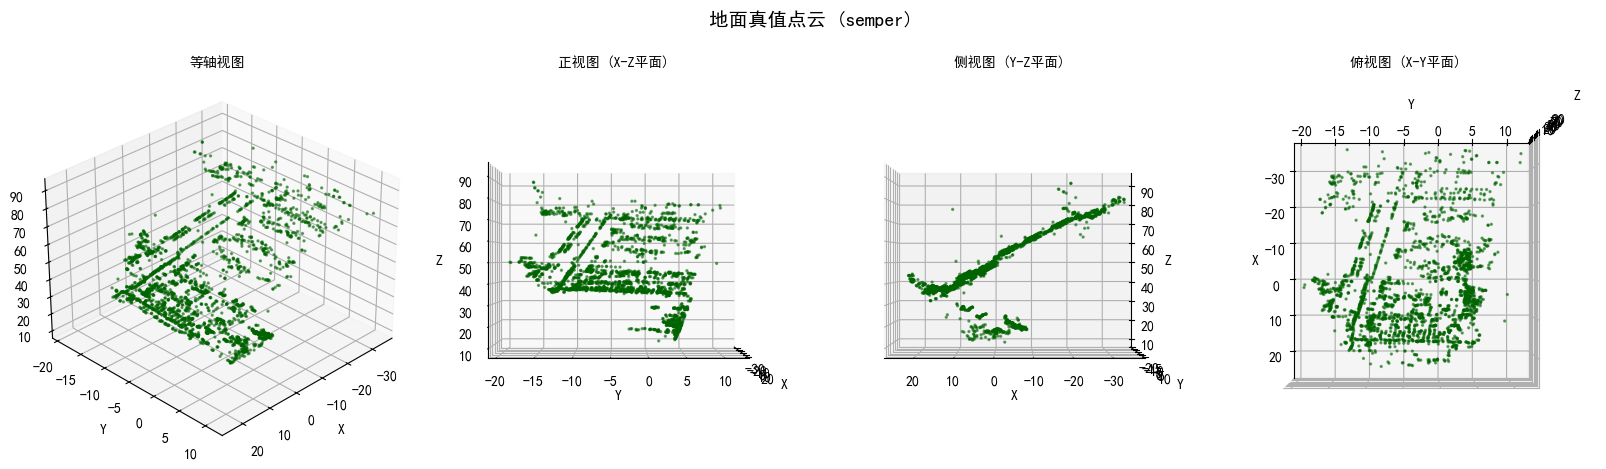

In [11]:
def load_3d_points(pts_file):
    """读取semper的3Dpoints文件。"""
    with open(pts_file, 'r') as f:
        lines = f.readlines()
    dim, n_pts = map(int, lines[0].strip().split())
    points = np.array([list(map(float, line.strip().split())) for line in lines[1:n_pts+1]])
    return points


# 加载地面真值点云
gt_points = load_3d_points(DATA_DIR / "rdimage.000.ppm.3Dpoints")
print(f"地面真值点数量: {len(gt_points)}")
print(f"真值点云范围:")
print(f"  X: [{gt_points[:,0].min():.2f}, {gt_points[:,0].max():.2f}]")
print(f"  Y: [{gt_points[:,1].min():.2f}, {gt_points[:,1].max():.2f}]")
print(f"  Z: [{gt_points[:,2].min():.2f}, {gt_points[:,2].max():.2f}]")

# 可视化真值点云
fig = plt.figure(figsize=(16, 5))
for i, (elev, azim, title) in enumerate(views):
    ax = fig.add_subplot(1, 4, i + 1, projection='3d')
    ax.scatter(gt_points[:, 0], gt_points[:, 1], gt_points[:, 2], 
               c='darkgreen', s=2, alpha=0.5)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title, fontsize=10)
    ax.view_init(elev=elev, azim=azim)
plt.suptitle('地面真值点云 (semper)', fontsize=14)
plt.tight_layout()
plt.show()


### 9.1 重投影误差评估

将三角化得到的3D点重新投影回图像，与原始特征点比较，计算平均重投影误差。

重投影误差反映了几何一致性的好坏，是评估三维重建质量的重要指标。

图1 重投影误差: 均值=5.2963px, 中位数=4.8345px
图2 重投影误差: 均值=5.2781px, 中位数=4.7955px
总体平均重投影误差: 5.2872px


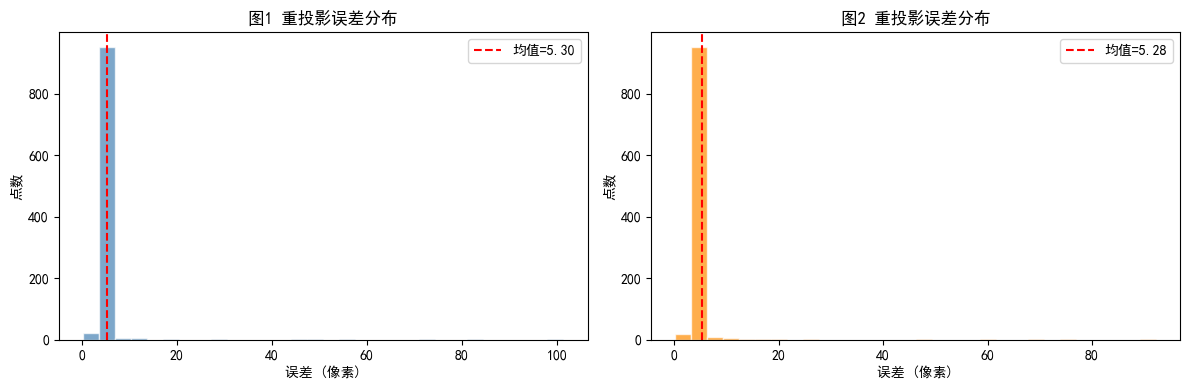

In [12]:
# 计算重投影误差
P1 = K1_scaled @ np.hstack([np.eye(3), np.zeros((3, 1))])
P2 = K2_scaled @ np.hstack([R_recovered, t_recovered.reshape(3, 1)])

# 转为齐次坐标
X_h = np.hstack([points_3d_recovered, np.ones((len(points_3d_recovered), 1))])

# 投影到图1
proj1_h = (P1 @ X_h.T).T  # N×3
proj1 = proj1_h[:, :2] / proj1_h[:, 2:3]
errors1 = np.linalg.norm(proj1 - pts1, axis=1)

# 投影到图2
proj2_h = (P2 @ X_h.T).T
proj2 = proj2_h[:, :2] / proj2_h[:, 2:3]
errors2 = np.linalg.norm(proj2 - pts2, axis=1)

print(f"图1 重投影误差: 均值={np.mean(errors1):.4f}px, 中位数={np.median(errors1):.4f}px")
print(f"图2 重投影误差: 均值={np.mean(errors2):.4f}px, 中位数={np.median(errors2):.4f}px")
print(f"总体平均重投影误差: {np.mean(np.concatenate([errors1, errors2])):.4f}px")

# 误差分布直方图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(errors1, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title('图1 重投影误差分布')
axes[0].set_xlabel('误差 (像素)')
axes[0].set_ylabel('点数')
axes[0].axvline(np.mean(errors1), color='red', linestyle='--', label=f'均值={np.mean(errors1):.2f}')
axes[0].legend()

axes[1].hist(errors2, bins=30, color='darkorange', alpha=0.7, edgecolor='white')
axes[1].set_title('图2 重投影误差分布')
axes[1].set_xlabel('误差 (像素)')
axes[1].set_ylabel('点数')
axes[1].axvline(np.mean(errors2), color='red', linestyle='--', label=f'均值={np.mean(errors2):.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()


## 十、保存点云与相机参数

将重建的点云和相机参数保存到文件。

- **TXT格式**：X Y Z 三列，老师要求的格式，可用 **CloudCompare** 直接打开查看
- **PLY格式**：带颜色信息，兼容 MeshLab / CloudCompare

### CloudCompare 使用方法
1. 下载安装 CloudCompare（免费开源）
2. `File -> Open`，选择 `point_cloud.txt`
3. 在导入对话框中确认列对应关系：第1列=X，第2列=Y，第3列=Z
4. 导入后用鼠标左键旋转、滚轮缩放查看三维点云结构


In [13]:
output_dir = Path(".")

# ====== 保存点云 (TXT格式，老师要求的格式，可直接用CloudCompare打开) ======
txt_file = output_dir / "point_cloud.txt"
with open(txt_file, 'w', encoding='utf-8') as f:
    f.write("# 3D 点云坐标 (X, Y, Z)\n")
    f.write(f"# 点数: {len(points_3d_recovered)}\n")
    f.write("# 格式: X Y Z\n")
    for p in points_3d_recovered:
        f.write(f"{p[0]:.6f} {p[1]:.6f} {p[2]:.6f}\n")
print(f"点云(TXT)已保存: {txt_file}")

# 同时保存PLY格式（带颜色，方便MeshLab等查看）
ply_file = output_dir / "reconstructed_point_cloud.ply"
with open(ply_file, 'w') as f:
    f.write("ply\n")
    f.write("format ascii 1.0\n")
    f.write(f"element vertex {len(points_3d_recovered)}\n")
    f.write("property float x\n")
    f.write("property float y\n")
    f.write("property float z\n")
    f.write("property uchar red\n")
    f.write("property uchar green\n")
    f.write("property uchar blue\n")
    f.write("end_header\n")
    for p in points_3d_recovered:
        z_norm = np.clip((p[2] - points_3d_recovered[:,2].min()) / 
                         (points_3d_recovered[:,2].max() - points_3d_recovered[:,2].min()), 0, 1)
        r = int(255 * z_norm)
        b = int(255 * (1 - z_norm))
        f.write(f"{p[0]:.6f} {p[1]:.6f} {p[2]:.6f} {r} {100} {b}\n")
print(f"点云(PLY)已保存: {ply_file}")

# 保存相机参数
cam_file = output_dir / "camera_params.txt"
with open(cam_file, 'w', encoding='utf-8') as f:
    f.write("# 恢复的相机参数（相机2相对于相机1）\n")
    f.write("\n# 相机1内参 K1 (缩放后):\n")
    for row in K1_scaled:
        f.write(f"  {row[0]:.4f} {row[1]:.4f} {row[2]:.4f}\n")
    f.write("\n# 相机2内参 K2 (缩放后):\n")
    for row in K2_scaled:
        f.write(f"  {row[0]:.4f} {row[1]:.4f} {row[2]:.4f}\n")
    f.write("\n# 相对旋转矩阵 R (相机2->相机1):\n")
    for row in R_recovered:
        f.write(f"  {row[0]:.6f} {row[1]:.6f} {row[2]:.6f}\n")
    f.write("\n# 相对平移向量 t:\n")
    f.write(f"  {t_recovered[0]:.6f} {t_recovered[1]:.6f} {t_recovered[2]:.6f}\n")
    f.write(f"\n# 重投影误差 (平均): {np.mean(np.concatenate([errors1, errors2])):.4f} px\n")
print(f"相机参数已保存: {cam_file}")

print("\n" + "="*50)
print("用 CloudCompare 查看点云：")
print("  1. 打开 CloudCompare")
print("  2. File -> Open，选择 point_cloud.txt")
print("  3. 在弹出的对话框中确认列对应 X Y Z")
print("  4. 用鼠标旋转/缩放查看三维结构")
print("="*50)

点云(TXT)已保存: point_cloud.txt
点云(PLY)已保存: reconstructed_point_cloud.ply
相机参数已保存: camera_params.txt

用 CloudCompare 查看点云：
  1. 打开 CloudCompare
  2. File -> Open，选择 point_cloud.txt
  3. 在弹出的对话框中确认列对应 X Y Z
  4. 用鼠标旋转/缩放查看三维结构


## 十一、拓展：RANSAC鲁棒估计
实际应用中匹配点常包含外点（错误匹配），8点法对异常值敏感。
RANSAC通过随机抽样来鲁棒地估计F，能有效处理外点。

**思考题**：如何用RANSAC改进基础矩阵估计？请在练习中尝试。

提示：每次随机选8对点估计F，然后统计内点数量（满足对极约束误差小于阈值的点对），迭代多次取内点最多的F。

## 十二、本章小结

### 核心算法流程
```
双视图图像
    ↓ SIFT + BFMatcher
特征匹配点对
    ↓ 归一化8点法
基础矩阵 F (rank=2)
    ↓ E = K2^T F K1
本质矩阵 E
    ↓ SVD分解 → 4组候选
    ↓ cheirality检验（正深度）
相机相对位姿 (R, t)
    ↓ 线性三角化 (DLT + SVD)
三维点云
```

### 关键知识点
1. **对极约束**：$x_2^T F x_1 = 0$，匹配点必在对应极线上
2. **8点法**：最少8对点求解F，必须归一化+rank-2约束
3. **E分解**：4组 (R,t) 候选，cheirality选正确解
4. **尺度不确定性**：双视图SfM只能恢复到尺度，绝对尺度需额外信息
5. **三角化**：DLT构造4×4方程组，SVD求最小二乘解
6. **重投影误差**：评估重建质量的核心指标

### 常见易错点
- ❌ 忘记归一化 → F矩阵病态，结果不稳定
- ❌ 忘记强制rank=2 → 对极约束不严格
- ❌ R行列式不为1 → 不是合法旋转矩阵（含反射）
- ❌ 混淆R的方向（世界→相机 vs 相机→世界）
- ❌ 三角化后忘记除以齐次坐标的最后一维


## 十三、练习与思考

### 练习1：RANSAC鲁棒F估计
在8点法基础上实现RANSAC，从包含外点的匹配中鲁棒估计F，对比纯8点法的效果。

### 练习2：第三视图扩展
使用第三张图像 (`rdimage.002.ppm`)，尝试将三张图联合重建，观察点云质量提升。

### 练习3：点云精度定量评估
将重建点云与地面真值点云做ICP对齐，计算平均距离误差。

### 思考题
1. 为什么基础矩阵F有7个自由度而不是9个？
2. 为什么本质矩阵E只有5个自由度？
3. 双视图重建为什么存在尺度不确定性？在什么条件下可以确定绝对尺度？
4. 如果只有7对匹配点，能否求解F？有多少个解？


---

## 十四、练习参考答案

### 练习1：RANSAC鲁棒F估计

RANSAC（随机抽样一致）通过迭代随机采样最小子集（8对点）来估计F，然后统计内点数量，最终选取内点最多的模型。

**算法步骤**：
1. 随机选取8对匹配点
2. 用8点法估计F
3. 计算所有点对的对极约束误差（Sampson距离），统计内点（误差<阈值）
4. 重复迭代，保留内点最多的F
5. 用所有内点重新计算F（优化）

RANSAC内点数量: 969 / 992 (97.7%)

RANSAC估计的 F:
[[ 1.53025534e-06  9.14029571e-05 -4.13929388e-02]
 [-6.58704133e-05 -5.99487686e-06 -2.37386621e-01]
 [ 3.22566768e-02  2.27162166e-01  1.00000000e+00]]

纯8点法 平均残差: 59.9357 px^2
RANSAC 平均残差: 83.2495 px^2
RANSAC内点平均残差: 0.0492 px^2


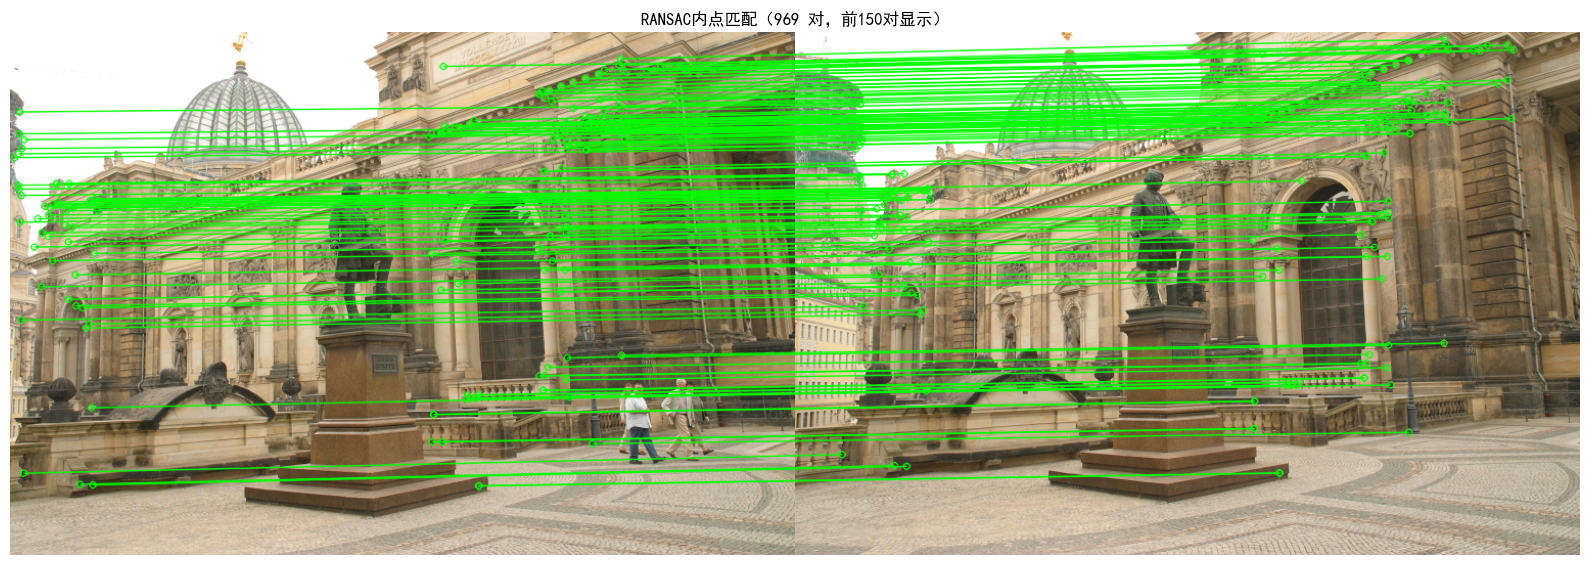

In [14]:
import random
import math

def compute_residual(F, pts1, pts2):
    """计算每对匹配点的对极约束误差（Sampson距离）。"""
    N = len(pts1)
    residuals = np.zeros(N)
    for i in range(N):
        x1 = np.array([pts1[i, 0], pts1[i, 1], 1.0])
        x2 = np.array([pts2[i, 0], pts2[i, 1], 1.0])
        # Sampson距离（近似几何距离）
        Fx1 = F @ x1
        Ftx2 = F.T @ x2
        denom = Fx1[0]**2 + Fx1[1]**2 + Ftx2[0]**2 + Ftx2[1]**2
        if denom > 1e-10:
            residuals[i] = (x2 @ F @ x1)**2 / denom
        else:
            residuals[i] = 1e10
    return residuals


def ransac_fundamental(pts1, pts2, threshold=1.0, max_iter=1000, seed=42):
    """RANSAC鲁棒估计基础矩阵F。
    
    参数:
        pts1, pts2: Nx2 匹配点坐标
        threshold: 内点阈值（像素）
        max_iter: 最大迭代次数
    返回:
        F_best: 最优基础矩阵
        inliers: 内点索引
    """
    rng = np.random.RandomState(seed)
    N = len(pts1)
    best_inliers = []
    best_F = None
    
    for _ in range(max_iter):
        # 随机选8对点
        idx = rng.choice(N, 8, replace=False)
        sample_pts1 = pts1[idx]
        sample_pts2 = pts2[idx]
        
        try:
            F = compute_fundamental_8point(sample_pts1, sample_pts2)
        except:
            continue
        
        # 计算残差
        residuals = compute_residual(F, pts1, pts2)
        inliers = np.where(residuals < threshold**2)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_F = F
            
            # 自适应更新迭代次数
            inlier_ratio = len(inliers) / N
            if inlier_ratio > 0:
                p = 0.99  # 置信度
                k = math.log(1 - p) / math.log(1 - inlier_ratio**8)
                max_iter = min(max_iter, int(k) + 1)
    
    # 用所有内点重新计算F（优化）
    if len(best_inliers) >= 8:
        best_F = compute_fundamental_8point(pts1[best_inliers], pts2[best_inliers])
    
    return best_F, best_inliers


# 测试 RANSAC
F_ransac, inliers = ransac_fundamental(pts1, pts2, threshold=2.0, max_iter=2000)
print(f"RANSAC内点数量: {len(inliers)} / {len(pts1)} ({len(inliers)/len(pts1)*100:.1f}%)")
print(f"\nRANSAC估计的 F:")
print(F_ransac)

# 对比纯8点法的对极约束误差
errors_8pt = compute_residual(F_my, pts1, pts2)
errors_ransac = compute_residual(F_ransac, pts1, pts2)
print(f"\n纯8点法 平均残差: {np.mean(errors_8pt):.4f} px^2")
print(f"RANSAC 平均残差: {np.mean(errors_ransac):.4f} px^2")
print(f"RANSAC内点平均残差: {np.mean(errors_ransac[inliers]):.4f} px^2")

# 可视化内点匹配
inlier_matches = [good_matches[i] for i in inliers]
img_inlier = cv2.drawMatches(img1, kp1, img2, kp2, inlier_matches[:150], None,
                              flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
                              matchColor=(0, 255, 0))
plt.figure(figsize=(16, 6))
plt.imshow(cv2.cvtColor(img_inlier, cv2.COLOR_BGR2RGB))
plt.title(f'RANSAC内点匹配（{len(inliers)} 对，前150对显示）')
plt.axis('off')
plt.tight_layout()
plt.show()

### 练习2：第三视图扩展

加入第三张图像，使用已恢复的相机1和相机2位姿作为基准，通过PnP求解第三相机的位姿，然后三角化更多3D点。

**思路**：
1. 提取图3的SIFT特征，与图1/图2匹配
2. 用已重建的3D点和图3中的2D对应点，通过PnP求解相机3的位姿
3. 用三视三角化或两两三角化得到更稠密的点云

图3特征点数: 2000
图1-图3 良好匹配: 935 对
PnP可用的 3D-2D 对应点: 699 对

PnP成功: True
内点数: 633 / 699

相机3旋转矩阵 R (相对相机1):
[[ 0.99854508  0.00128874  0.05390787]
 [-0.00107772  0.99999164 -0.00394333]
 [-0.0539125   0.0038795   0.99853813]]

相机3平移向量 t:
[-1.9180931  -0.18761359 -0.94668315]

合并后点云总数: 1927


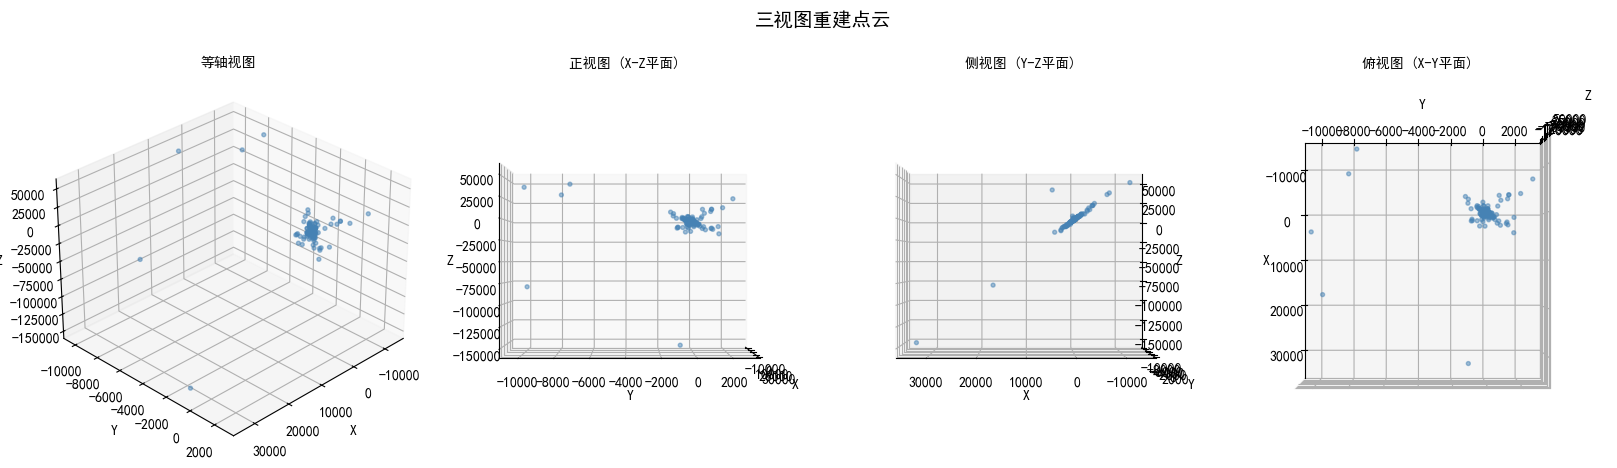

In [15]:
# 读取第三张图像
img3_full = cv2.imread(str(DATA_DIR / "rdimage.002.ppm"))
img3 = cv2.resize(img3_full, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
img3_gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

K3_scaled = K1_scaled.copy()  # 假设相机内参相同

# 提取图3特征
kp3, des3 = sift.detectAndCompute(img3_gray, None)
print(f"图3特征点数: {len(kp3)}")

# 图1-图3匹配
knn_13 = bf.knnMatch(des1, des3, k=2)
good_13 = [m for m, n in knn_13 if m.distance < 0.75 * n.distance]
print(f"图1-图3 良好匹配: {len(good_13)} 对")

# 建立匹配点索引映射：图1特征点索引 -> 三角化后的3D点索引
kp1_to_3d = {}  # queryIdx -> 3D point index
for i, m in enumerate(good_matches):
    kp1_to_3d[m.queryIdx] = i

# 收集：图3的2D点 <-> 对应的3D点（通过图1作为桥梁）
obj_points = []  # 3D点
img_points = []  # 图3中的2D点

for m in good_13:
    if m.queryIdx in kp1_to_3d:
        idx_3d = kp1_to_3d[m.queryIdx]
        obj_points.append(points_3d_recovered[idx_3d])
        img_points.append(kp3[m.trainIdx].pt)

obj_points = np.array(obj_points, dtype=np.float64)
img_points = np.array(img_points, dtype=np.float64)
print(f"PnP可用的 3D-2D 对应点: {len(obj_points)} 对")

# PnP求解相机3位姿（相机3相对于相机1）
if len(obj_points) >= 6:
    dist_coeffs = np.zeros(5)  # 假设无畸变
    success, rvec, tvec, inliers_pnp = cv2.solvePnPRansac(
        obj_points, img_points, K3_scaled, dist_coeffs,
        iterationsCount=1000, reprojectionError=3.0
    )
    R3, _ = cv2.Rodrigues(rvec)
    t3 = tvec.flatten()
    print(f"\nPnP成功: {success}")
    print(f"内点数: {len(inliers_pnp)} / {len(obj_points)}")
    print(f"\n相机3旋转矩阵 R (相对相机1):")
    print(R3)
    print(f"\n相机3平移向量 t:")
    print(t3)
    
    # 三视三角化：图1-图3匹配的点用相机1和相机3做三角化
    pts1_13 = np.float64([kp1[m.queryIdx].pt for m in good_13])
    pts3_13 = np.float64([kp3[m.trainIdx].pt for m in good_13])
    
    P3 = K3_scaled @ np.hstack([R3, t3.reshape(3, 1)])
    P1_mat = K1_scaled @ np.hstack([np.eye(3), np.zeros((3, 1))])
    points_3d_13 = triangulate_linear(P1_mat, P3, pts1_13, pts3_13)
    
    # 合并点云（简单合并）
    all_points = np.vstack([points_3d_recovered, points_3d_13])
    print(f"\n合并后点云总数: {len(all_points)}")
    
    # 可视化三视图点云
    fig = plt.figure(figsize=(16, 5))
    for i, (elev, azim, title) in enumerate(views):
        ax = fig.add_subplot(1, 4, i + 1, projection='3d')
        ax.scatter(all_points[:, 0], all_points[:, 1], all_points[:, 2], 
                   c='steelblue', s=8, alpha=0.5)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        ax.set_title(title, fontsize=10)
        ax.view_init(elev=elev, azim=azim)
    plt.suptitle('三视图重建点云', fontsize=14)
    plt.tight_layout()
    plt.show()

### 练习3：点云精度定量评估（ICP对齐）

由于SfM重建的点云和真值点云不在同一坐标系（尺度、旋转、平移均不同），
需要通过**相似变换**（Umeyama算法）将重建点云对齐到真值点云，然后计算平均距离误差。

**简化ICP流程**：
1. 对每个重建点，在真值点云中找最近邻作为对应点
2. 用Umeyama算法求解最优相似变换（R, t, s）
3. 应用变换到重建点云
4. 重复直到收敛

运行ICP对齐...

对齐后平均距离: 38.7309
对齐后中位距离: 1.9395
RMSE: 453.9756


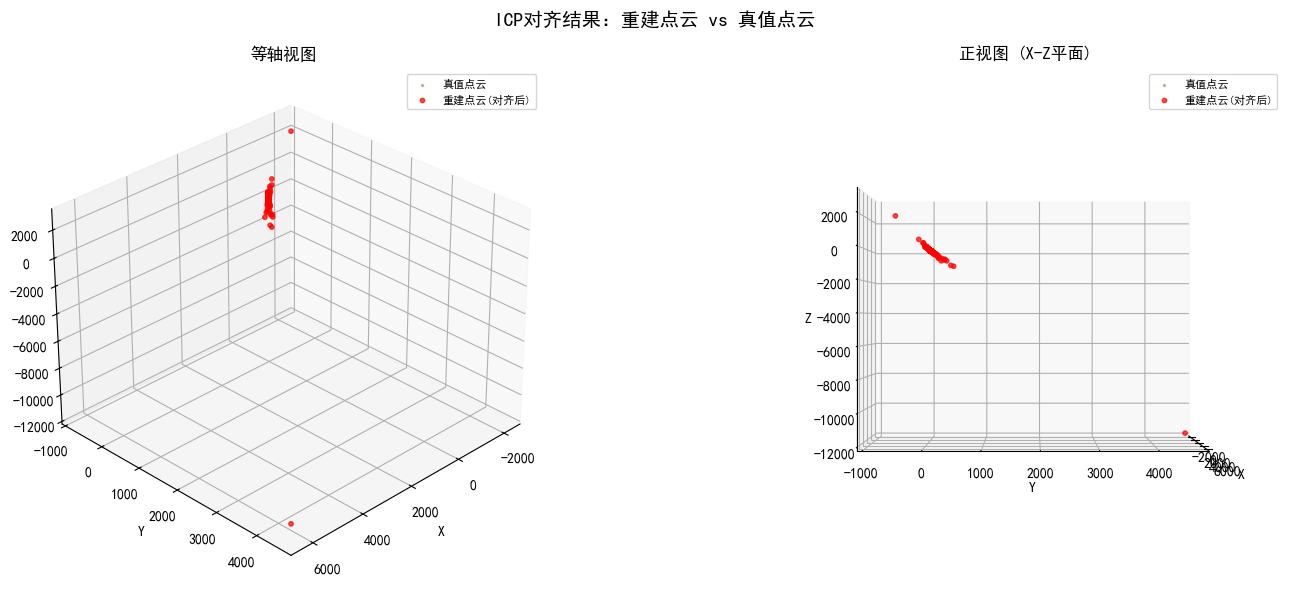

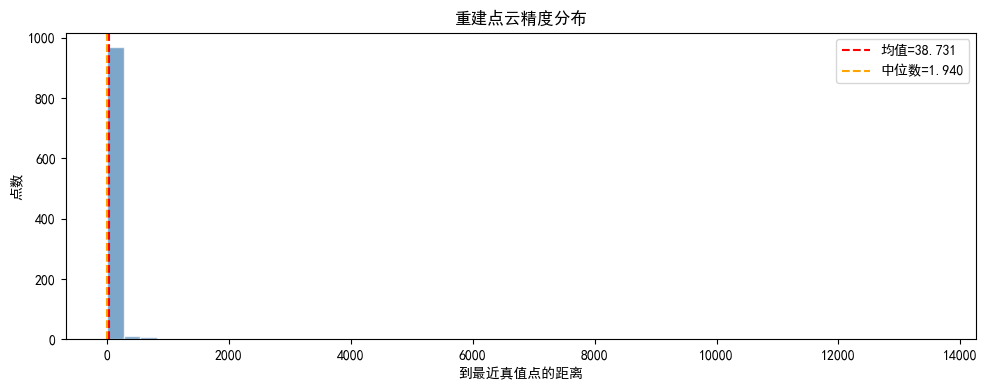

In [16]:
from scipy.spatial import cKDTree

def umeyama_alignment(src, dst):
    """Umeyama算法：求解最优相似变换（R, t, s）使 s*R*src + t ~= dst。
    
    输入: src, dst - Nx3 对应点集
    输出: R (3x3), t (3,), s (scalar)
    """
    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)
    
    src_centered = src - src_mean
    dst_centered = dst - dst_mean
    
    # 协方差矩阵
    H = src_centered.T @ dst_centered / len(src)
    
    # SVD
    U, S, Vt = np.linalg.svd(H)
    
    # 确保旋转（det=1）
    d = np.linalg.det(Vt.T @ U.T)
    D = np.diag([1, 1, np.sign(d)])
    
    R = Vt.T @ D @ U.T
    
    # 尺度
    var_src = np.mean(np.sum(src_centered**2, axis=1))
    s = np.trace(np.diag(S) @ D) / var_src
    
    # 平移
    t = dst_mean - s * R @ src_mean
    
    return R, t, s


def simplified_icp(src_pts, tgt_pts, max_iter=30, tol=1e-4):
    """简化版ICP：用最近邻找对应，Umeyama对齐。"""
    tree = cKDTree(tgt_pts)
    src = src_pts.copy()
    prev_err = np.inf
    
    for it in range(max_iter):
        # 找最近邻对应
        distances, indices = tree.query(src, k=1)
        tgt_corr = tgt_pts[indices]
        
        # 去除离群对应（距离大于中位数的2倍）
        med_dist = np.median(distances)
        mask = distances < 2 * med_dist
        
        if mask.sum() < 10:
            break
        
        # Umeyama对齐
        R, t, s = umeyama_alignment(src[mask], tgt_corr[mask])
        
        # 应用变换
        src = s * (R @ src.T).T + t
        
        # 检查收敛
        mean_err = np.mean(distances[mask])
        if abs(prev_err - mean_err) < tol:
            print(f"ICP在第 {it+1} 次迭代收敛")
            break
        prev_err = mean_err
    
    # 最终误差
    distances, _ = tree.query(src, k=1)
    return src, distances


# 运行ICP对齐
print("运行ICP对齐...")
aligned_points, distances = simplified_icp(points_3d_recovered, gt_points, max_iter=20)

print(f"\n对齐后平均距离: {np.mean(distances):.4f}")
print(f"对齐后中位距离: {np.median(distances):.4f}")
print(f"RMSE: {np.sqrt(np.mean(distances**2)):.4f}")

# 可视化对齐结果
fig = plt.figure(figsize=(16, 6))

for i, (elev, azim, title) in enumerate(views[:2]):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    ax.scatter(gt_points[:, 0], gt_points[:, 1], gt_points[:, 2], 
               c='darkgreen', s=2, alpha=0.3, label='真值点云')
    ax.scatter(aligned_points[:, 0], aligned_points[:, 1], aligned_points[:, 2], 
               c='red', s=10, alpha=0.7, label='重建点云(对齐后)')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.view_init(elev=elev, azim=azim)

plt.suptitle('ICP对齐结果：重建点云 vs 真值点云', fontsize=14)
plt.tight_layout()
plt.show()

# 误差分布
plt.figure(figsize=(10, 4))
plt.hist(distances, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
plt.axvline(np.mean(distances), color='red', linestyle='--', label=f'均值={np.mean(distances):.3f}')
plt.axvline(np.median(distances), color='orange', linestyle='--', label=f'中位数={np.median(distances):.3f}')
plt.xlabel('到最近真值点的距离')
plt.ylabel('点数')
plt.title('重建点云精度分布')
plt.legend()
plt.tight_layout()
plt.show()

### 思考题参考答案

**1. 为什么基础矩阵F有7个自由度而不是9个？**

F是3x3矩阵，表面上有9个元素，但有两个约束：
- **尺度不变性**：F定义到相差一个尺度因子（即 kF 和 F 表示同一对极几何），所以减去1个自由度
- **秩-2约束**：F的行列式必须为0（rank(F)=2），这是一个非线性约束，再减去1个自由度

所以 9 - 1 - 1 = **7个自由度**。

**2. 为什么本质矩阵E只有5个自由度？**

E描述的是两个归一化相机之间的对极几何，等价于描述两个相机的相对位姿：
- 相对旋转 R：3个自由度
- 相对平移 t：3个自由度，但尺度未定（对极几何无法恢复绝对尺度）

所以 3 + 3 - 1 = **5个自由度**。

等价地，E的奇异值为 [sigma, sigma, 0]，两个相等的非零奇异值+一个零奇异值，也说明了约束更强。

**3. 双视图重建为什么存在尺度不确定性？在什么条件下可以确定绝对尺度？**

对极约束中，如果把平移 t 放大 k 倍，同时把所有3D点也放大 k 倍，投影到图像上的坐标不变。也就是说，尺度在投影过程中被'消掉'了。

确定绝对尺度的方法：
- 已知场景中某个物体的真实尺寸（如标定板边长）
- 已知相机基线的真实长度
- 有IMU等传感器提供尺度信息
- 三视图及以上且有非共面运动时，可通过场景的几何约束部分恢复尺度

**4. 如果只有7对匹配点，能否求解F？有多少个解？**

可以求解，但不是唯一解。7对点给出7个线性方程，加上det(F)=0的非线性约束（三次方程），理论上最多有 **3个解**。这就是所谓的'7点法'。

在RANSAC框架中，7点法也常被使用，因为只需更少的采样点，且能利用rank-2约束从一开始就保证解的合法性。

## 十二、手算示例：对极约束到底约束了什么？

**（1）对极约束公式**

设 $p_1, p_2$ 是两幅图中对应点的**齐次像素坐标**，$F$ 为基础矩阵，则必须满足：

$$
p_2^{T} F p_1 = 0
$$

取一个简单的 $F$：

$$
F = \begin{bmatrix} 0 & -1 & 0 \\ 1 & 0 & 0 \\ 0 & 0 & 0 \end{bmatrix}
\qquad
p_1 = \begin{bmatrix} 1 \\ 0 \\ 1 \end{bmatrix}
$$

**（2）先求第二幅图中的极线**

$$
l_2 = F p_1
= \begin{bmatrix} 0\cdot1 + (-1)\cdot0 + 0\cdot1 \\ 1\cdot1 + 0\cdot0 + 0\cdot1 \\ 0 \end{bmatrix}
= \begin{bmatrix} 0 \\ 1 \\ 0 \end{bmatrix}
\;\Longrightarrow\;
0 \cdot u + 1 \cdot v + 0 = 0
\;\Longrightarrow\;
\boxed{v = 0}
$$

即：**$p_1$ 的对应点必定落在第二幅图的水平中线上**。

**（3）验证约束**

| $p_2$ | $p_2^{T} F p_1$ | 是否可能对应 |
|-------|:--:|:--:|
| $(5,\ 0,\ 1)$ | $5\times0 + 0\times1 + 1\times0 = 0$ | ✓ 在极线上 |
| $(0,\ 0,\ 1)$ | $0$ | ✓ 在极线上 |
| $(5,\ 3,\ 1)$ | $5\times0 + 3\times1 + 1\times0 = 3 \ne 0$ | ✗ 不可能 |

**（4）为什么至少要 8 对点**

$F$ 是 $3\times3$ 齐次矩阵，且满足 $\det(F) = 0$：

$$
\text{自由度} = 9 - 1\ (\text{尺度等价}) - 1\ (\det F = 0) = 7
$$

每对匹配点提供 **1 个**方程 → 至少需要 **7 对**；工程上取 **8 对**（8 点法），多出的一个方程用于归一化取最小奇异向量。

> ★ **关键观察**：对极约束把"在第二幅图里找一个点"从**二维搜索降成一维搜索**（只需沿极线找）。
> 这是立体匹配能把复杂度压下来的根本原因，也是极线校正（把极线拉成水平）的动机。
>
> ★ **关键观察**：8 点法对**像素坐标未归一化**极其敏感——坐标量级在上百，
> 构成矩阵的列量级相差几个数量级，数值条件数很差。
> 所以实现里必须先做**归一化 8 点法**（平移到质心、缩放到平均距离 $\sqrt{2}$），
> 解完再反归一化。少了这一步，结果会明显不稳。
>
> ★ **关键观察**：从 $F$ 到 $E$ 再到位姿时，$E = K_2^{T} F K_1$ 分解出的 4 组解中，
> 只有**同时满足 cheirality（点都在两个相机前方）**的那一组才是物理上正确的——
> 数学解不等价于物理解，必须用三角化后的深度符号来挑选。

### 参考来源

| 类别 | 来源 |
|------|------|
| 教材 | [上海交通大学《动手学习计算机视觉》](https://github.com/boyu-ai/Hands-on-CV)（图片、公式与代码组织方式的主要来源） |
| 课程 | Stanford CS231A L5-L7（对极几何、本质矩阵、SfM）· CMU 16-385（双目几何） |
| 作业 | 见下方「对应课程作业与解答」 |


## 课程参考与拓展阅读

### 对应大学课程

| 课程 | 讲座 | 对应内容 |
|------|------|----------|
| Stanford CS231A L5 | Epipolar Geometry | 基础矩阵F、本质矩阵E、8点法 |
| Stanford CS231A L6 | Stereo Systems | 三角化、cheirality check |
| Stanford CS231A L7 | Structure from Motion | SfM完整流程 |
| Stanford CS231A PS2 | Problem Set 2 | 双视图重建作业 |
| CMU 16-385 PA3 | 3D Reconstruction | 三维重建作业 |

### 参考资源

- [CS231A PS2 PDF](https://stanford.edu/class/cs231a/hw_2025_spring/ps2.pdf) | [Code](https://stanford.edu/class/cs231a/hw_2025_spring/ps2_code.zip)
- [CS231A L5 slides](https://stanford.edu/class/cs231a/lectures_2025/lecture5_epipolar_geometry.pdf)
- [CS231A L7 SFM slides](https://stanford.edu/class/cs231a/lectures_2025/lecture7_SFM_silvio_2025.pdf)
- [GitHub解答](https://github.com/zyxrrr/cs231a/tree/master/ps2)
- [CMU 16-385 PA3](https://16385.courses.cs.cmu.edu/spring2026/assets/assignments/assgn3.zip)

### 高观看量技术文章

1. [对极几何与三维重建三步法](https://blog.csdn.net/m0_37755875/article/details/146854834)
2. [Essential Matrix详解](https://zhuanlan.zhihu.com/p/377792783)
3. [Hartley & Zisserman, "Multiple View Geometry"](https://www.robots.ox.ac.uk/~vgg/hzbook/)

## 对应课程作业与解答

### 作业来源：Stanford CS231A Problem Set 2 — Epipolar Geometry & 3D Reconstruction

> **课程链接**：[CS231A Spring 2025](https://web.stanford.edu/class/cs231a/)
>
> **作业PDF**：[PS2](https://stanford.edu/class/cs231a/hw_2025_spring/ps2.pdf) | [Code](https://stanford.edu/class/cs231a/hw_2025_spring/ps2_code.zip)
>
> **截止日期**：May 2, 2025
>
> **GitHub解答**：[zyxrrr/cs231a ps2/](https://github.com/zyxrrr/cs231a/tree/master/ps2)
>
> **对应讲座**：L5 Epipolar Geometry | L6 Stereo Systems | L7 Structure from Motion

**题目1（PS2）：8点法求基础矩阵**

> 给定 $N \geq 8$ 对匹配点，用8点法求解基础矩阵 $F$。

**解答（来自 [ps2/fundamental_matrix_estimation.py](https://github.com/zyxrrr/cs231a/blob/master/ps2/fundamental_matrix_estimation.py)）：**

- `lls_eight_point_alg()`: 基础8点法，构造 $N \times 9$ 矩阵，SVD求最小奇异值向量
- `normalized_eight_point_alg()`: Hartley归一化版，将点坐标平移到原点并缩放，提高数值稳定性
- `compute_distance_to_epipolar_lines()`: 评估F矩阵质量

> ★ **关键观察**：Hartley归一化（将点坐标平移到原点并缩放到平均距离$\sqrt{2}$）是8点法稳定性的关键。不做归一化时，$A$矩阵条件数很大，SVD数值精度差。

**题目2（PS2）：本质矩阵分解 + 三角化 + SfM**

> 从本质矩阵 $E$ 分解出4组 $(R, T)$ 解，用cheirality约束选出正确解，然后三角化求3D点。

**解答（来自 [ps2/triangulation.py](https://github.com/zyxrrr/cs231a/blob/master/ps2/triangulation.py)）：**

- `estimate_initial_RT()`: SVD分解 $E = U\Sigma V^T$，4组解 $(UWV^T, \pm U_3)$ 和 $(UW^TV^T, \pm U_3)$
- `linear_estimate_3d_point()`: 线性SVD三角化
- `nonlinear_estimate_3d_point()`: Gauss-Newton迭代优化3D点（9次迭代）
- `estimate_RT_from_E()`: cheirality check — 选使三角化点深度为正的 $(R,T)$

**题目3（PS2）：Tomasi-Kanade分解法 + Bundle Adjustment**

> - `factorization_method()`: 从两视图匹配点用SVD分解恢复结构和运动
> - `bundle_adjustment()`: Levenberg-Marquardt联合优化相机运动和3D结构

> **参考**：[CS231A L5 Epipolar Geometry](https://stanford.edu/class/cs231a/lectures_2025/lecture5_epipolar_geometry.pdf) | [Hartley & Zisserman, MVG Ch.9-11](https://www.robots.ox.ac.uk/~vgg/hzbook/)

In [17]:
# ==================== CS231A PS2 作业解答代码 ====================
# 代码出处：https://github.com/zyxrrr/cs231a/blob/master/ps2/
# 修改：适配Jupyter Notebook格式，添加中文注释

import numpy as np

# ============ 题目1: 基础矩阵估计 ============
# 来源: https://github.com/zyxrrr/cs231a/blob/master/ps2/fundamental_matrix_estimation.py

def lls_eight_point_alg(points1, points2):
    """
    基础8点法: 构造Nx9矩阵W, SVD求F
    对每对点 p=(u,v,1), p'=(u',v',1): p'^T F p = 0
    """
    # 构造W矩阵: 每行 [u'*u, u'*v, u', v'*u, v'*v, v', u, v, 1]
    temp1 = np.tile(points1[:, 0:1], (1, 3))  # u重复3列
    temp2 = np.tile(points1[:, 1:2], (1, 3))  # v重复3列
    temp3 = np.tile(points1[:, 2:3], (1, 3))  # 1重复3列
    points1_rep = np.concatenate((temp1, temp2, temp3), axis=1)
    
    temp = np.tile(points2, (1, 3))  # p'重复3组
    W = np.multiply(points1_rep, temp)  # 逐元素乘
    
    # SVD: F = V的最后一行reshape为3x3
    _, _, V = np.linalg.svd(W)
    f = V[-1, :]
    F = np.reshape(f, (3, 3))
    
    # 强制秩2约束: F = U diag(s1,s2,0) V^T
    U, s, V = np.linalg.svd(F)
    S = np.diag(s)
    S[2, 2] = 0  # 最小奇异值置零
    F = U @ S @ V
    return F

def normalized_eight_point_alg(points1, points2):
    """
    Hartley归一化8点法:
    1. 将点坐标平移到原点（减均值）
    2. 缩放到平均距离sqrt(2)
    3. 在归一化坐标系下用8点法
    4. 反归一化: F = T2^T F_norm T1
    """
    # --- 归一化第一组点 ---
    p1Ave = np.average(points1, axis=0)
    T1 = np.array([[1, 0, -p1Ave[0]], [0, 1, -p1Ave[1]], [0, 0, 1]])
    p1_centered = (T1 @ points1.T).T
    s1 = 1 / p1_centered[:, :2].max()
    S1 = np.diag([s1, s1, 1])
    T1 = S1 @ T1
    P1t = (T1 @ points1.T).T
    
    # --- 归一化第二组点 ---
    p2Ave = np.average(points2, axis=0)
    T2 = np.array([[1, 0, -p2Ave[0]], [0, 1, -p2Ave[1]], [0, 0, 1]])
    p2_centered = (T2 @ points2.T).T
    s2 = 1 / p2_centered[:, :2].max()
    S2 = np.diag([s2, s2, 1])
    T2 = S2 @ T2
    P2t = (T2 @ points2.T).T
    
    # 在归一化坐标系下求F
    F_norm = lls_eight_point_alg(P1t, P2t)
    
    # 反归一化
    F = T2.T @ F_norm @ T1
    return F

def compute_distance_to_epipolar_lines(points1, points2, F):
    """计算点到对极线的平均距离（评估F质量）"""
    p2 = points2.T
    epLine2 = F @ p2  # 第二幅图的对极线
    p1 = points1.T
    # 点到线的距离 = |l^T * p| / sqrt(l1^2 + l2^2)
    temp1 = np.sum(np.multiply(epLine2, p1), axis=0)
    epLine2[2:3, :] = 0  # 只用前两行算分母
    temp2 = np.sqrt(np.sum(np.multiply(epLine2, epLine2), axis=0))
    dis1 = np.divide(temp1, temp2)
    return np.average(dis1)

# ============ 题目2: 本质矩阵分解 + 三角化 ============
# 来源: https://github.com/zyxrrr/cs231a/blob/master/ps2/triangulation.py

def estimate_initial_RT(E):
    """
    从本质矩阵E分解出4组(R,T)解
    E = U Sigma V^T, 4组解: (UWV^T,±U3), (UW^TV^T,±U3)
    """
    U, s, V = np.linalg.svd(E)
    W = np.array([[0, -1, 0], [1, 0, 0], [0, 0, 1]])
    
    Q1 = U @ W @ V
    Q2 = U @ W.T @ V
    # 确保行列式为1
    R1 = np.linalg.det(Q1) * Q1
    R2 = np.linalg.det(Q2) * Q2
    T1 = U[:, 2:3]
    T2 = -T1
    
    # 4组解
    RT = np.zeros((4, 3, 4))
    RT[0] = np.hstack([R1, T1])
    RT[1] = np.hstack([R1, T2])
    RT[2] = np.hstack([R2, T1])
    RT[3] = np.hstack([R2, T2])
    return RT

def linear_estimate_3d_point(image_points, camera_matrices):
    """
    线性SVD三角化: 从多视图2D点恢复3D点
    原理: x × (P * X) = 0 → AX = 0 → SVD
    """
    n = image_points.shape[0]
    A = np.zeros((2 * n, 4))
    for idx in range(n):
        # x*(P3行) - P1行 = 0, y*(P3行) - P2行 = 0
        A[2*idx] = image_points[idx, 0] * camera_matrices[idx, 2, :] - camera_matrices[idx, 0, :]
        A[2*idx+1] = image_points[idx, 1] * camera_matrices[idx, 2, :] - camera_matrices[idx, 1, :]
    
    _, _, Vt = np.linalg.svd(A)
    point_3d = Vt[-1, :]
    return point_3d[:3] / point_3d[3]  # 非齐次化

def reprojection_error(point_3d, image_points, camera_matrices):
    """计算重投影误差向量"""
    n = image_points.shape[0]
    point_3d_h = np.append(point_3d, 1)
    error = np.zeros((2 * n, 1))
    for idx in range(n):
        projected = camera_matrices[idx] @ point_3d_h
        projected = projected / projected[2]  # 齐次坐标归一化
        error[2*idx:2*idx+2, 0] = projected[:2] - image_points[idx]
    return error

def nonlinear_estimate_3d_point(image_points, camera_matrices, n_iter=9):
    """
    非线性三角化: Gauss-Newton迭代优化3D点
    先线性估计初值，再用GN迭代9次
    """
    point_3d = linear_estimate_3d_point(image_points, camera_matrices)
    
    for _ in range(n_iter):
        # 数值雅可比（有限差分）
        eps = 1e-6
        jac = np.zeros((2 * len(image_points), 3))
        for k in range(3):
            delta = np.zeros(3)
            delta[k] = eps
            err_plus = reprojection_error(point_3d + delta, image_points, camera_matrices)
            err_minus = reprojection_error(point_3d - delta, image_points, camera_matrices)
            jac[:, k] = (err_plus - err_minus).flatten() / (2 * eps)
        
        err = reprojection_error(point_3d, image_points, camera_matrices)
        # Gauss-Newton: delta = (J^T J)^{-1} J^T * err
        try:
            delta = np.linalg.inv(jac.T @ jac) @ (jac.T @ err)
            point_3d = point_3d - delta.flatten()
        except np.linalg.LinAlgError:
            break
    
    return point_3d

def estimate_RT_from_E(E, image_points, K):
    """
    从E选择正确的(R,T): cheirality check
    正确解应使三角化的3D点在两个相机前方（深度Z>0）
    """
    n = image_points.shape[0]
    RT = estimate_initial_RT(E)
    flag = np.zeros(4)
    
    camera0 = K @ np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0]])
    
    for i in range(4):
        rt = RT[i]
        camera1 = K @ rt
        cams = np.array([camera0, camera1])
        
        count = 0
        for j in range(min(n, 50)):  # 检查前50个点
            try:
                pt3d = nonlinear_estimate_3d_point(image_points[j], cams)
            except:
                continue
            # cheirality: 3D点在两个相机前方
            pt_h = np.append(pt3d, 1)
            # 第二个相机坐标系下的深度
            pt_cam2 = rt @ pt_h
            if pt3d[2] > 0 and pt_cam2[2] > 0:
                count += 1
        flag[i] = count
    
    best = np.argmax(flag)
    return RT[best]

# ============ 题目3: Tomasi-Kanade分解法 ============
# 来源: https://github.com/zyxrrr/cs231a/blob/master/ps2/factorization_method.py
def factorization_method(points_im1, points_im2):
    """
    Tomasi-Kanade分解法: 从两视图恢复结构和运动
    1. 中心化: 减去均值
    2. 堆叠测量矩阵 D (4xN)
    3. SVD分解: D = U S V^T
    4. 结构 S = sqrt(Σ3) V3, 运动 M = U3 sqrt(Σ3)
    """
    # 中心化
    p1Ave = np.average(points_im1, axis=0)
    p2Ave = np.average(points_im2, axis=0)
    p1Centered = points_im1 - p1Ave
    p2Centered = points_im2 - p2Ave
    
    # 堆叠测量矩阵 D (4xN)
    D = np.concatenate((p1Centered[:, :2].T, p2Centered[:, :2].T), axis=0)
    
    # SVD分解
    U, s, V = np.linalg.svd(D)
    S = np.diag(s)[:3, :3]
    
    # 分解为运动和结构
    motion = U[:, :3] @ np.sqrt(S)     # 4x3 运动矩阵
    structure = np.sqrt(S) @ V[:3, :]  # 3xN 结构矩阵
    
    return structure.T, motion

print("CS231A PS2 作业解答代码已加载")
print("来源: https://github.com/zyxrrr/cs231a/blob/master/ps2/")
print("")
print("函数列表:")
print("  lls_eight_point_alg          - 基础8点法求F")
print("  normalized_eight_point_alg   - Hartley归一化8点法")
print("  compute_distance_to_epipolar_lines - 评估F质量")
print("  estimate_initial_RT          - E分解为4组(R,T)")
print("  linear_estimate_3d_point     - 线性SVD三角化")
print("  nonlinear_estimate_3d_point  - Gauss-Newton非线性三角化")
print("  estimate_RT_from_E           - cheirality check选择正确RT")
print("  factorization_method         - Tomasi-Kanade分解法")
print("")
print("参考: CS231A L5 Epipolar Geometry, L6 Stereo, L7 SfM")
print("      Hartley & Zisserman, MVG Ch.9-11")


CS231A PS2 作业解答代码已加载
来源: https://github.com/zyxrrr/cs231a/blob/master/ps2/

函数列表:
  lls_eight_point_alg          - 基础8点法求F
  normalized_eight_point_alg   - Hartley归一化8点法
  compute_distance_to_epipolar_lines - 评估F质量
  estimate_initial_RT          - E分解为4组(R,T)
  linear_estimate_3d_point     - 线性SVD三角化
  nonlinear_estimate_3d_point  - Gauss-Newton非线性三角化
  estimate_RT_from_E           - cheirality check选择正确RT
  factorization_method         - Tomasi-Kanade分解法

参考: CS231A L5 Epipolar Geometry, L6 Stereo, L7 SfM
      Hartley & Zisserman, MVG Ch.9-11
